<a href="https://colab.research.google.com/github/treborskrub/Fundamental-Cores/blob/main/agentpi_mesh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Generating pure Pi digit coordinate fabric... Please wait.

--- Tracing Trajectory for Seed: 169 ---
Step   | Current State   | Next Position   | Delta      | Gate Status
---------------------------------------------------------------------------
#1     | 169             | 41              | 128        | OPEN (1) - Kinetic Flow / Orbit
#2     | 41              | 3               | 38         | OPEN (1) - Kinetic Flow / Orbit
#3     | 3               | 1               | 2          | OPEN (1) - Kinetic Flow / Orbit
#4     | 1               | 2               | 1          | OPEN (1) - Kinetic Flow / Orbit
#5     | 2               | 7               | 5          | OPEN (1) - Kinetic Flow / Orbit
#6     | 7               | 14              | 7          | OPEN (1) - Kinetic Flow / Orbit
#7     | 14              | 2               | 12         | OPEN (1) - Kinetic Flow / Orbit
#8     | 2               | 7               | 5          | OPEN (1) - Kinetic Flow / Orbit
>> Perpetual Orbit Detected! Cycl

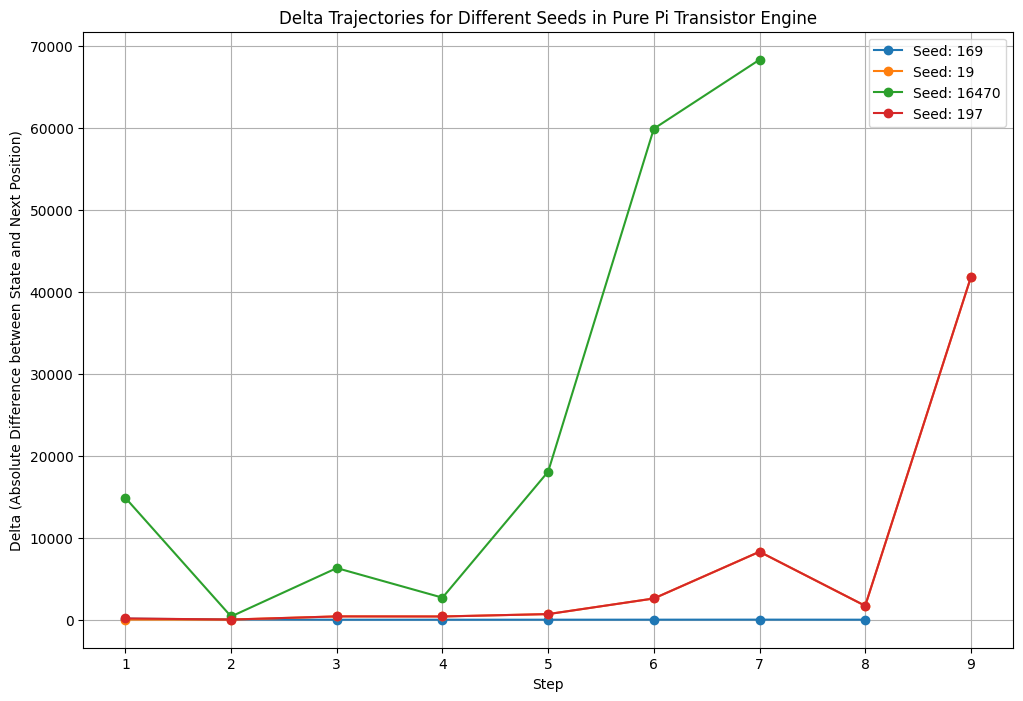

In [ ]:
import mpmath
import matplotlib.pyplot as plt

def generate_pi_string(digits=100000):
    """
    Generates the decimal expansion of Pi as a clean, continuous string
    to act as our deterministic coordinate address space.
    """
    # Set precision slightly higher than requested digits to avoid rounding flaws
    mpmath.mp.dps = digits + 2
    pi_str = str(mpmath.mp.pi).replace('.', '')
    return pi_str

class PurePiTransistorEngine:
    def __init__(self, pi_digits_pool):
        """
        Initializes the engine with a static pool of Pi's decimal digits.
        The digits string acts as the hardware architecture.
        """
        self.pi_str = pi_digits_pool

    def lookup_position(self, x):
        """
        The Core Pi-Mapping Function f(x).
        Searches for where the value 'x' first appears as a string of digits
        in the decimal expansion of Pi, returning its 1-based index position.
        """
        search_target = str(x)
        # Using 1-based indexing to perfectly match standard Pi-Search engine metrics
        idx = self.pi_str.find(search_target)

        if idx == -1:
            return None
        return idx + 1

    def evaluate_gate_state(self, current_state):
        """
        Evaluates the transistor gate based on the pure geometric distance (delta)
        between the state's identity (value) and its spatial coordinate (position).
        """
        next_state = self.lookup_position(current_state)

        if next_state is None:
            return {
                "status": "TERMINATED (Out of Bounds / Increase Digit Pool)",
                "next_state": None,
                "delta": None,
                "gate_firing": False
            }

        # Calculate the pure spatial tension/offset (The Dynamic Delta)
        delta = abs(current_state - next_state)

        # GATE LOGIC RULE:
        # If delta == 0, it's a self-locating string (Dead End). State cannot evolve. GATE CLOSES (0).
        # If delta > 0, the state possesses dimensional tension and is moving. GATE OPENS (1).
        gate_firing = (delta != 0)

        if gate_firing:
            status = "OPEN (1) - Kinetic Flow / Orbit"
        else:
            status = "CLOSED (0) - Dead End Latched Sink"

        return {
            "status": status,
            "next_state": next_state,
            "delta": delta,
            "gate_firing": gate_firing
        }

    def trace_trajectory(self, seed, max_steps=15):
        """
        Traces a state trajectory from an initial seed through its feedback path,
        mapping loops, basins, and sinks in real time.
        """
        print(f"\n--- Tracing Trajectory for Seed: {seed} ---")
        print(f"{'Step':<6} | {'Current State':<15} | {'Next Position':<15} | {'Delta':<10} | {'Gate Status'}")
        print("-" * 75)

        state = seed
        visited_states = {}

        for step in range(1, max_steps + 1):
            metrics = self.evaluate_gate_state(state)

            # Print row execution metrics
            next_state_str = str(metrics['next_state']) if metrics['next_state'] else "N/A"
            delta_str = str(metrics['delta']) if metrics['delta'] is not None else "N/A"

            print(f"#{step:<5} | {state:<15} | {next_state_str:<15} | {delta_str:<10} | {metrics['status']}")

            # Check for structural closure (Dead End Sink)
            if not metrics['gate_firing']:
                print(f">> System permanently latched at Dead End: {state} (Delta=0). Flow halted.")
                break

            if metrics['next_state'] is None:
                break

            # Check for cyclical repetition (Perpetual Loop Orbit)
            if state in visited_states:
                print(f">> Perpetual Orbit Detected! Cycle length = {step - visited_states[state]} steps.")
                break

            visited_states[state] = step
            state = metrics['next_state']

    def get_delta_trajectory(self, seed, max_steps=15):
        """
        Traces a state trajectory and returns a list of delta values.
        """
        deltas = []
        state = seed
        visited_states = {}

        for step in range(1, max_steps + 1):
            metrics = self.evaluate_gate_state(state)

            if metrics['delta'] is not None:
                deltas.append(metrics['delta'])

            if not metrics['gate_firing'] or metrics['next_state'] is None:
                break

            if state in visited_states:
                # Cycle detected, stop collecting deltas for this path
                break

            visited_states[state] = step
            state = metrics['next_state']

        return deltas

# --- Execution Block ---
if __name__ == "__main__":
    # 1. Initialize the digit fabric (100,000 digits handles standard small loops flawlessly)
    print("Generating pure Pi digit coordinate fabric... Please wait.")
    pi_pool = generate_pi_string(100000)

    # 2. Fire up the engine
    engine = PurePiTransistorEngine(pi_pool)

    # 3. Define test targets to showcase different structural responses
    test_cases = [
        169,   # Initiates the famous "40 Loop"
        19,    # Initiates the tight 3-step perpetual cycle
        16470, # A native self-locating coordinate string (Fixed-point sink)
        197    # A random transient number that gets captured by an orbit basin
    ]

    # 4. Run diagnostics on each structural archetype
    for seed in test_cases:
        engine.trace_trajectory(seed, max_steps=12)

    # 5. Visualize delta trajectories
    plt.figure(figsize=(12, 8))

    for seed in test_cases:
        deltas = engine.get_delta_trajectory(seed, max_steps=12)
        plt.plot(range(1, len(deltas) + 1), deltas, marker='o', label=f'Seed: {seed}')

    plt.title('Delta Trajectories for Different Seeds in Pure Pi Transistor Engine')
    plt.xlabel('Step')
    plt.ylabel('Delta (Absolute Difference between State and Next Position)')
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
import mpmath
import numpy as np

# =====================================================================
# 1. CORE SYSTEM CONSTANTS & ROM
# =====================================================================
def generate_fabric_rom(digits=100000):
    mpmath.mp.dps = digits + 2
    return str(mpmath.mp.pi).replace('.', '')

# =====================================================================
# 2. THE 32-BIT VIRTUAL HARDWARE PIPELINE
# =====================================================================
class PhotonicAgentCPU:
    def __init__(self, fabric_rom):
        self.fabric = fabric_rom
        # Architectural registers (Processor1.pdf Specifications)
        self.pc = 0                 # Program Counter (Queue Head)
        self.status_error = 0       # STATUS.ERROR bit flag
        self.current_mode = 0       # 0x0 = Standard Mode (S-Mode)
        self.s_i = 0.1              # Internal phase state tracking register s[i]

    def coordinate_lookup(self, x, offset=0):
        """Finds positional index matching Newpi.pdf logic."""
        search_target = str(x)
        idx = self.fabric.find(search_target, offset)
        if idx == -1:
            return None
        return (idx - offset) + 1

    def execute_analog_wave_ops(self, tick, coordinate):
        """Executes micro-op math equations from page 16 of specifications."""
        phi_weight = (1 + np.sqrt(5)) / 2  # φ profile constant
        x_input = 0.5                      # Incoming sample x[i]

        # (b) Compute π reference term
        r_i = np.sin(2 * np.pi * self.s_i)

        # (c) Compute φ-weighted term
        w_i = phi_weight * self.s_i * x_input

        # (d) Compute combined output potential y[i]
        y_i = (r_i + w_i) / 2.0

        # (e) Modulate internal phase loop: s[i] = (s[i] + |y[i]|) mod 1
        next_s_i = (self.s_i + np.abs(y_i)) % 1.0
        self.s_i = next_s_i

        return y_i

    def process_instruction_queue(self, hex_queue):
        """
        Executes the formal 6-stage lifecycle per word (Page 13-14):
        FETCH -> DECODE -> VALIDATE -> EXECUTE -> WRITEBACK -> ADVANCE
        """
        print(f"================ STARTING PIPELINE EXECUTION ENGINE ================")
        print(f"Initial Register State: s[i] = {self.s_i:.4f} | S-Mode Active")
        print("=" * 105)
        print(f"{'PC':<4} | {'Raw Hex':<11} | {'Mnemonic':<15} | {'Fields (M/F/A0/A1)':<19} | {'Coordinate':<12} | {'Wave Out y[i]'}")
        print("-" * 105)

        while self.pc < len(hex_queue):
            # 1. FETCH
            raw_word = hex_queue[self.pc]

            # 2. DECODE (Bit-accurate extraction formulas from Page 8 & 12)
            opcode = (raw_word >> 24) & 0xFF
            mode   = (raw_word >> 20) & 0x0F
            flags  = (raw_word >> 16) & 0x0F
            arg0   = (raw_word >> 8) & 0xFF
            arg1   = raw_word & 0xFF

            mnemonic = "UNKNOWN"
            coord_result = "N/A"
            wave_out = 0.0

            # 3. VALIDATE & 4. EXECUTE
            if opcode == 0x10:
                mnemonic = "LOADPHIPROFILE"
                # Page 14-15 micro-ops: Determine targeting lane arrays
                lane_id = arg0 if (flags & 0x02) == 0 else arg1
                mnemonic += f" (L:{lane_id})"

            elif opcode == 0x20:
                mnemonic = "RUN_TICKS"
                # Page 15-16 micro-ops: Reconstruct immediate tick value or coordinate target
                target_seed = (arg0 << 8) | arg1 if (flags & 0x02) != 0 else arg1

                # Direct lookup inside the numerical fabric matching Newpi.pdf mapping
                next_addr = self.coordinate_lookup(target_seed)
                if next_addr is not None:
                    coord_result = f"{next_addr}"
                    # Compute continuous hardware waveforms driven by current location
                    wave_out = self.execute_analog_wave_ops(self.pc, next_addr)
                else:
                    coord_result = "OUT_OF_BOUNDS"

            elif opcode == 0x40:
                mnemonic = "SET_MODE"
                if mode == 0x0:
                    self.current_mode = 0 # Explicitly commit Standard Mode

            elif opcode == 0x50:
                mnemonic = "DEBUG_CTRL"
                mnemonic += f" (Fn:{mode})"

            else:
                # Illegal instruction rule flag
                self.status_error = 1
                mnemonic = "ILLEGAL_OP"

            # Formatting values for clean console logging
            fields_str = f"M:{mode} F:{flags} A0:{arg0} A1:{arg1}"
            wave_str = f"{wave_out:>13.6f}" if coord_result != "N/A" else f"{'N/A':>13}"

            print(f"#{self.pc:<3} | {hex(raw_word):<11} | {mnemonic:<15} | {fields_str:<19} | {coord_result:<12} | {wave_str}")

            # 5. WRITEBACK & 6. ADVANCE
            self.pc += 1

# =====================================================================
# 3. RUNTIME MISSION DEMO
# =====================================================================
if __name__ == "__main__":
    pi_pool = generate_fabric_rom(100000)
    cpu = PhotonicAgentCPU(pi_pool)

    # An agent's compiled structural plan written directly as an ISA machine code stream:
    agent_mission_bytecode = [
        0x40000000,  # SET_MODE: Force Standard S-Mode initialization
        0x1000050C,  # LOADPHIPROFILE: Configure profile index 12 to lane index 5
        0x20020013,  # RUN_TICKS: Read immediate target coordinate seed 19
        0x20024056,  # RUN_TICKS: Read immediate target coordinate seed 16470 (Static Sink)
        0x50100000,  # DEBUG_CTRL: Trigger dump function 1 to flush core registers
        0x99000000   # INVALID: Test the illegal instruction status exception rule
    ]

    cpu.process_instruction_queue(agent_mission_bytecode)

================ STARTING PIPELINE EXECUTION ENGINE ================
Initial Register State: s[i] = 0.1000 | S-Mode Active
PC   | Raw Hex     | Mnemonic        | Fields (M/F/A0/A1)  | Coordinate   | Wave Out y[i]
---------------------------------------------------------------------------------------------------------
#0   | 0x40000000  | SET_MODE        | M:0 F:0 A0:0 A1:0   | N/A          |           N/A
#1   | 0x1000050c  | LOADPHIPROFILE (L:5) | M:0 F:0 A0:5 A1:12  | N/A          |           N/A
#2   | 0x20020013  | RUN_TICKS       | M:0 F:2 A0:0 A1:19  | 38           |      0.334343
#3   | 0x20024056  | RUN_TICKS       | M:0 F:2 A0:64 A1:86 | 1603         |      0.376161
#4   | 0x50100000  | DEBUG_CTRL (Fn:1) | M:1 F:0 A0:0 A1:0   | N/A          |           N/A
#5   | 0x99000000  | ILLEGAL_OP      | M:0 F:0 A0:0 A1:0   | N/A          |           N/A


In [ ]:

import mpmath
import numpy as np

def generate_fabric_rom(digits=100000):
    mpmath.mp.dps = digits + 2
    return str(mpmath.mp.pi).replace('.', '')

class AutonomousAgentCPU:
    def __init__(self, fabric_rom):
        self.fabric = fabric_rom
        self.pc = 0
        self.status_error = 0
        self.current_mode = 0
        self.s_i = 0.1              # Internal phase state tracking register
        self.baseline = 1/3         # Your 1/3 voltage barrier

    def coordinate_lookup(self, x, offset=0):
        search_target = str(x)
        idx = self.fabric.find(search_target, offset)
        if idx == -1:
            return None
        return (idx - offset) + 1

    def execute_analog_wave_ops(self, coordinate):
        phi_weight = (1 + np.sqrt(5)) / 2
        x_input = 0.5

        r_i = np.sin(2 * np.pi * self.s_i)
        w_i = phi_weight * self.s_i * x_input
        y_i = (r_i + w_i) / 2.0

        # Modulate phase loop state
        self.s_i = (self.s_i + np.abs(y_i)) % 1.0
        return y_i

    def process_instruction_stream(self, bytecode_dictionary):
        """
        Executes instructions out of a dictionary map to handle dynamic
        hardware-level branching and memory page jumps autonomously.
        """
        print(f"================ INITIALIZING AUTONOMOUS AGENT RUNTIME ================")
        print(f"Tracking Core Matrix | Voltage Threshold Limit: {self.baseline:.4f}")
        print("=" * 110)
        print(f"{'ADDR/PC':<9} | {'Raw Hex':<11} | {'Mnemonic':<15} | {'Coordinate':<12} | {'Wave Potential':<16} | {'Pipeline Action'}")
        print("-" * 110)

        while self.pc in bytecode_dictionary:
            raw_word = bytecode_dictionary[self.pc]
            current_address = self.pc

            # Bitwise Decoder Pipeline
            opcode = (raw_word >> 24) & 0xFF
            mode   = (raw_word >> 20) & 0x0F
            flags  = (raw_word >> 16) & 0x0F
            arg0   = (raw_word >> 8) & 0xFF
            arg1   = raw_word & 0xFF

            mnemonic = "UNKNOWN"
            coord_result = "N/A"
            wave_out = 0.0
            action_status = "ADVANCE"

            if opcode == 0x10:
                mnemonic = "LOADPHIPROFILE"
                action_status = "NEXT_FRAME"
                self.pc += 1

            elif opcode == 0x20:
                mnemonic = "RUN_TICKS"
                target_seed = (arg0 << 8) | arg1 if (flags & 0x02) != 0 else arg1
                next_addr = self.coordinate_lookup(target_seed)

                if next_addr is not None:
                    coord_result = f"{next_addr}"
                    wave_out = self.execute_analog_wave_ops(next_addr)

                    # --- CRITICAL AUTONOMOUS BRANCHING CONDITION ---
                    # If the wave potential breaches the 1/3 limit, trigger an automatic hardware trap interrupt
                    if np.abs(wave_out) > self.baseline:
                        mnemonic += " [SPIKE]"
                        action_status = "VOLTAGE OVERFLOW -> TRAP INTERRUPT"
                        # Force hardware jump to the safety sub-routine block (Address 0x100)
                        self.pc = 0x100
                    else:
                        action_status = "STABLE_EXECUTION"
                        self.pc += 1
                else:
                    coord_result = "OUT_OF_BOUNDS"
                    self.pc += 1

            elif opcode == 0x30:
                mnemonic = "BRANCH_TARGET"
                action_status = "CONTAINMENT_LOCK"
                self.pc += 1

            elif opcode == 0x50:
                mnemonic = "DEBUG_CTRL"
                action_status = "SYSTEM_FLUSH"
                self.pc += 1

            else:
                mnemonic = "ILLEGAL_OP"
                self.pc += 1

            # Format readout fields
            wave_str = f"{wave_out:>12.6f}" if coord_result != "N/A" else f"{'N/A':>12}"
            print(f"0x{current_address:03x}    | {hex(raw_word):<11} | {mnemonic:<15} | {coord_result:<12} | {wave_str:<16} | {action_status}")

# =====================================================================
# SYSTEM MEMORY MAP (INSTRUCTION BLOCKS)
# =====================================================================
if __name__ == "__main__":
    pi_pool = generate_fabric_rom(100000)
    cpu = AutonomousAgentCPU(pi_pool)

    # Structure system memory as explicit memory addresses (Hex keys)
    system_memory_map = {
        # ---- Primary Execution Lane ----
        0x000: 0x1000050C,  # LOADPHIPROFILE
        0x001: 0x200200C5,  # RUN_TICKS: Seed 197 (Calculates an automatic waveform spike!)
        0x002: 0x20020013,  # RUN_TICKS: Seed 19 (This will get skipped entirely by the hardware jump!)

        # ---- Secure Threat Containment Sub-Routine (Address 0x100 Trap Target) ----
        0x100: 0x50100000,  # DEBUG_CTRL: Isolate and flush current thread parameters
        0x101: 0x30000000   # BRANCH_TARGET: Safely close identity horizon and loop back
    }

    cpu.process_instruction_stream(system_memory_map)

================ INITIALIZING AUTONOMOUS AGENT RUNTIME ================
Tracking Core Matrix | Voltage Threshold Limit: 0.3333
ADDR/PC   | Raw Hex     | Mnemonic        | Coordinate   | Wave Potential   | Pipeline Action
--------------------------------------------------------------------------------------------------------------
0x000    | 0x1000050c  | LOADPHIPROFILE  | N/A          |          N/A     | NEXT_FRAME
0x001    | 0x200200c5  | RUN_TICKS [SPIKE] | 38           |     0.334343     | VOLTAGE OVERFLOW -> TRAP INTERRUPT
0x100    | 0x50100000  | DEBUG_CTRL      | N/A          |          N/A     | SYSTEM_FLUSH
0x101    | 0x30000000  | BRANCH_TARGET   | N/A          |          N/A     | CONTAINMENT_LOCK
